In [11]:
#%pip install ../packages/sv-extraction --quiet

In [1]:
# define root folder
import os
from pathlib import Path

HERE = Path(os.getcwd()).parent

### Step 01 - Labelling ROIs on images

The first step in the Escore algorithm involve the labelling of regions of interest (*ROI*s) on echograms representing multifrequency acoustic data. To allow a smooth and fast labelling procedure, the `escore` module pre-computes and saves `.png` echogram images. Labelling is done by embedding the `LABELME` application.

We begin by creating an echogram labelling app instance. This object contains all the necessary information regarding source date (or *echointegration*), visual parameters (for the image dataset), and the name of library to which the newly create annotations will be added.

In [12]:
# instanciate labelling app
from sv_extraction import EcholabelApp

app = EcholabelApp(
    input="private/data/input/ABRACOS_A2",
    libname="ROI_lib_A2_3F",
    root=HERE,
    frequencies=[38., 70., 120.],
    echogram_cmap='RGB',
)

#TODO: Add a way to clean registry from empty images_datasets (or shapes, shapes_libraries...)
#TODO: Include test data

REGISTRY INFO 15:10:24: Echointegration already exists with id 2. (Line: 76 [echointegrations.py])
REGISTRY WARNING 15:10:24: Different casings for input data paths are treated as identical in registry. If you intended to add a different dataset, make sure the input files contained in the specified input folder differ from the already existing ones. (Line: 77 [echointegrations.py])
REGISTRY INFO 15:10:24: Image dataset already exists in registry with id 2 (Line: 103 [images.py])


App instanciation create a `EcholabelAppConfig` object (stored as the `.config` attribute of the app). The config contains all the static information for the app to run. Some of this information is compute on instanciation, such as the paths of the folders used by the app (most the app output will be stored in `/app_data/`).

The app interacts with a database, to keep track of data structures (echointegration > image dataset > annotation shapes).

Once the app is instanciated, it is run using a simple `.run()` method. This will:

1. Build an image dataset in the app's work directory (see *Note*)
2. Open `Labelme` as a subprocess
3. Store the results in the database
4. Output some information on the labelling session to the user




*Note*: The only argument of the method (`force_rebuild_images` specifies whether to re-print all the images when it has already been done before)

In [13]:
# run the labelling app
app.run(force_rebuild_images=False)

#TODO: Some bug when using the same library name on a different EI. Should be tested on app instanciation.
#TODO: when re-running with same app -> same session id + index re start : when creating new, WE ONLY MODIFY THE LAST ENTRIES IN REGISTRY
#TODO: Support AI masks (polygons OK)


Library synced down: imported from image folder /Users/gaspardringuenet/Projects/escore-python/app_data/echogram_images/ABRACOS02_EI_02/RGB_38_70_120kHz_TF10000_Z0--1_Sv-90--50dB sharing EI 02

==== Echogram labelling session ====

 - Id:		2026-04-03_1510
 - Name:	ROI_lib_A2_3F
 - Cruise:	ABRACOS02
 - EI:		3.0 Number of pings x 1.0 Range (meters) (EI id 2)
 - Images:	/Users/gaspardringuenet/Projects/escore-python/app_data/echogram_images/ABRACOS02_EI_02/RGB_38_70_120kHz_TF10000_Z0--1_Sv-90--50dB

labelme printed outputs:


2026-04-03 15:10:26.767 | INFO     | labelme.__main__:main:192 - Starting Labelme 5.11.4
qt.qpa.fonts: Populating font family aliases took 49 ms. Replace uses of missing font family "Monospace" with one that exists to avoid this cost. 
2026-04-03 15:10:27.029 | DEBUG    | labelme.app:_scan_image_files:2351 - found 56 images in '/Users/gaspardringuenet/Projects/escore-python/app_data/echogram_images/ABRACOS02_EI_02/RGB_38_70_120kHz_TF10000_Z0--1_Sv-90--50dB'
2026-04-03 15:10:27.033 | DEBUG    | labelme.app:_open_next_image:1980 - setting current row to 0
2026-04-03 15:10:27.174 | DEBUG    | labelme.app:_load_file:1882 - loaded file: '/Users/gaspardringuenet/Projects/escore-python/app_data/echogram_images/ABRACOS02_EI_02/RGB_38_70_120kHz_TF10000_Z0--1_Sv-90--50dB/ABRACOS02_EI_02_T0-10000_Z0--1.png'
2026-04-03 15:10:29.094 | DEBUG    | labelme.app:_load_file:1882 - loaded file: '/Users/gaspardringuenet/Projects/escore-python/app_data/echogram_images/ABRACOS02_EI_02/RGB_38_70_120kHz_TF1000



Updating shapes registry file at: /Users/gaspardringuenet/Projects/escore-python/app_data/registry.db

Labelling session shapes registry update: 
 * 0 new 
 * 0 modified 
 * 0 deleted 
 * Total number of shapes in library (ROI_lib_A2_3F): 340

Library synced up: available accross all 4 image datasets related to EI 02


### Step 02 - Extract echo-types

In [ ]:
# define root folder
import os
from pathlib import Path

HERE = Path(os.getcwd()).parent

from sv_extraction import EchotypesApp

app = EchotypesApp(root=HERE, registry=HERE/"app_data/registry.db")
app.run(
    debug=True, 
    jupyter_mode="external"
)

Dash app running on http://127.0.0.1:8050/


REGISTRY ERROR 15:36:00: Exception on /_dash-update-component [POST] (Line: 875 [app.py])
Traceback (most recent call last):
  File "/Users/gaspardringuenet/Projects/escore-python/env/lib/python3.11/site-packages/flask/app.py", line 917, in full_dispatch_request
    rv = self.dispatch_request()
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/gaspardringuenet/Projects/escore-python/env/lib/python3.11/site-packages/flask/app.py", line 902, in dispatch_request
    return self.ensure_sync(self.view_functions[rule.endpoint])(**view_args)  # type: ignore[no-any-return]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/gaspardringuenet/Projects/escore-python/env/lib/python3.11/site-packages/dash/_get_app.py", line 17, in wrap
    return ctx.run(func, self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/gaspardringuenet/Projects/escore-python/env/lib/python3.11/site-packages/dash/dash.py", line 1601, in dispatch
    res

### Fetch echo-types libary and manipulate echo-types

In [5]:
import xarray as xr

library_path = HERE / "private/data/echotypes_libs/A2_3F_Misc.nc"
lib_ds: xr.Dataset = xr.open_dataset(library_path, chunks={"obs": 10_000})

valid_obs = ((lib_ds.depth <= 250.) & (lib_ds.Sv != -150.)).obs.values
lib_ds = lib_ds.isel(obs=valid_obs)
lib_ds

<xarray.Dataset> Size: 180MB
Dimensions:            (obs: 3463469, echotype: 235, channel: 4)
Coordinates:
    echotype           (obs) int32 14MB dask.array<chunksize=(10000,), meta=np.ndarray>
  * channel            (channel) float64 32B 38.0 70.0 120.0 200.0
    latitude           (obs) float64 28MB dask.array<chunksize=(10000,), meta=np.ndarray>
    longitude          (obs) float64 28MB dask.array<chunksize=(10000,), meta=np.ndarray>
    time               (obs) datetime64[ns] 28MB dask.array<chunksize=(10000,), meta=np.ndarray>
    depth              (obs) float64 28MB dask.array<chunksize=(10000,), meta=np.ndarray>
Dimensions without coordinates: obs
Data variables:
    shape_id           (echotype) object 2kB dask.array<chunksize=(235,), meta=np.ndarray>
    clustering_method  (echotype) object 2kB dask.array<chunksize=(235,), meta=np.ndarray>
    echotype_id        (echotype) int32 940B dask.array<chunksize=(235,), meta=np.ndarray>
    cluster_id         (echotype) int32 940B dask.array<chunksize=(235,), meta=np.ndarray>
    Sv                 (channel, obs) float32 55MB dask.array<chunksize=(4, 10000), meta=np.ndarray>
Attributes:
    echotype_library_name:  A2_3F_Misc
    ei_id:                  2
    cruise_name:            ABRACOS02
    description:            Sparse echotype Sv observations

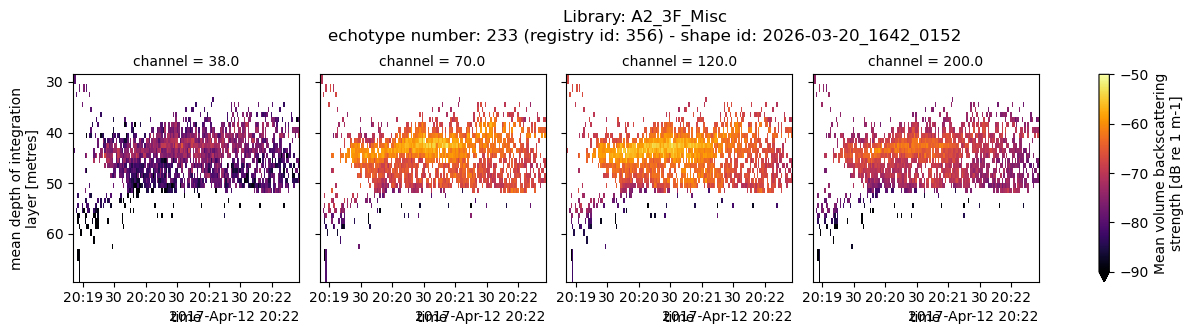

In [6]:
# Plot a random echotype's echogram
import numpy as np

e = np.random.choice(np.unique(lib_ds.echotype), size=1).item()

echotype_sv: xr.DataArray = (
    lib_ds
    .Sv
    .load()
    .where(lib_ds.echotype==e, drop=True)
    .set_index(obs=["time", "depth"])
    .unstack("obs")
)

g = echotype_sv.plot(x="time", yincrease=False, col='channel', col_wrap=4, vmin=-90, vmax=-50, cmap="inferno")

g.fig.suptitle(f"Library: {lib_ds.attrs.get('echotype_library_name')}"
               f"\nechotype number: {e}"
               f" (registry id: {lib_ds.echotype_id.sel(echotype=e).values.item()})"
               f" - shape id: {lib_ds.shape_id.sel(echotype=e).values.item()}",
               y=1.1);